# Turbofan Engine Degradation & RUL / Risk Scoring Analysis
Converted from `ML_project01.py` into Jupyter Notebook with cell-by-cell execution.

In [1]:
# PHASE-1(CUSTOM DATASET & CLUSTERING)
#Load-Inspect Data & Define Columns Names
import os
import pandas as pd
import numpy as np

column_names = ['unit','time'] + [f'operational_set{i}' for i in range(1,4)] + [f'sensor{i}' for i in range(1,22)]

# Dataset directory configuration (support CMaps/ folder or current directory)
DATA_DIR = 'CMaps' if os.path.exists('CMaps') else '.'

combinations = {
    "FD001_FD003": [os.path.join(DATA_DIR, "train_FD001.txt"), os.path.join(DATA_DIR, "train_FD003.txt")],
    "FD002_FD004": [os.path.join(DATA_DIR, "train_FD002.txt"), os.path.join(DATA_DIR, "train_FD004.txt")],
    "FD001_FD002_FD003_FD004": [os.path.join(DATA_DIR, "train_FD001.txt"), os.path.join(DATA_DIR, "train_FD002.txt"), os.path.join(DATA_DIR, "train_FD003.txt"), os.path.join(DATA_DIR, "train_FD004.txt")]
}

clustered_data = {}

In [2]:
#Preprocessing for Each Combination
from sklearn.preprocessing import StandardScaler

for combo_name, files in combinations.items():
    all_data = []
    for file in files:
        df = pd.read_csv(file, sep=r'\s+', header=None)
        df.columns = column_names
        df = df.dropna(axis=1)
        all_data.append(df)
    data = pd.concat(all_data, ignore_index=True)

    features = data.drop(['unit', 'time'], axis=1)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(features)

    data_scaled = pd.DataFrame(X_scaled, columns=features.columns)
    clustered_data[combo_name] = {'raw': data, 'scaled': data_scaled}

In [3]:
#KMean Clustering
from sklearn.cluster import KMeans

for combo_name in clustered_data:
    kmeans = KMeans(n_clusters=5, random_state=42)
    labels = kmeans.fit_predict(clustered_data[combo_name]['scaled'])
    clustered_data[combo_name]['raw']['cluster'] = labels
clustered_data

In [4]:
#Analyze Clusters & Label Stages

for combo_name in clustered_data:
    print(f"\nCluster Means for {combo_name}:")
    mean_df = clustered_data[combo_name]['raw'].groupby('cluster').mean()
    print(mean_df.head())


Cluster Means for FD001_FD003:
              unit        time  ...   sensor20   sensor21
cluster                         ...                      
0        51.102588  101.482625  ...  38.809728  23.285439
1        41.093488  122.258372  ...  38.959716  23.376820
2        50.076013  191.745705  ...  38.577005  23.146098
3        50.940153  287.053932  ...  39.394342  23.639749
4        50.918679   95.199468  ...  39.042109  23.424631

[5 rows x 26 columns]

Cluster Means for FD002_FD004:
               unit        time  ...   sensor20   sensor21
cluster                          ...                      
0        127.617085  122.490598  ...  12.194015   7.315856
1        128.144717  122.368765  ...  38.902571  23.342877
2        126.777318  123.165335  ...  14.288042   8.573778
3        126.954918  122.437286  ...  24.496239  14.698321
4        127.696247  122.406813  ...  28.585058  17.150574

[5 rows x 26 columns]

Cluster Means for FD001_FD002_FD003_FD004:
               unit        

In [5]:
#Assign Degradation Labels

cluster_stages={
    3:1,                    #Slightly degraded
    1:2,                    #Moderately degraded
    0:3,                    #Critical
    4:4,                    #Failure
    2:0                     #Normal
}

for combo_name in clustered_data:
    clustered_data[combo_name]['raw']['stages'] = clustered_data[combo_name]['raw']['cluster'].map(cluster_stages)

In [6]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

for combo_name in clustered_data:
    data_scaled = clustered_data[combo_name]['scaled']
    sample_indices = np.random.choice(len(data_scaled), size=5000, replace=False)
    sample_data = data_scaled.iloc[sample_indices]

    agglo = AgglomerativeClustering(n_clusters=5)
    agglo_labels = agglo.fit_predict(sample_data)

    clustered_data[combo_name]['raw']['agg_cluster'] = -1
    clustered_data[combo_name]['raw'].loc[sample_indices, 'agg_cluster'] = agglo_labels

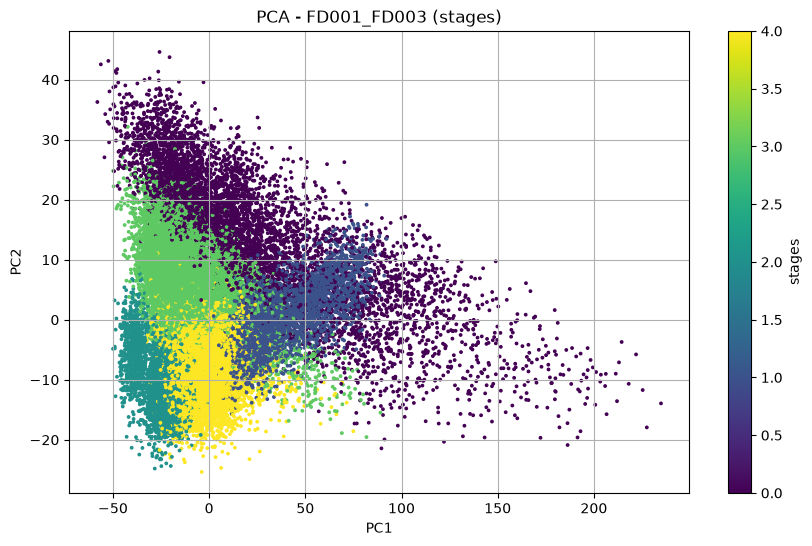

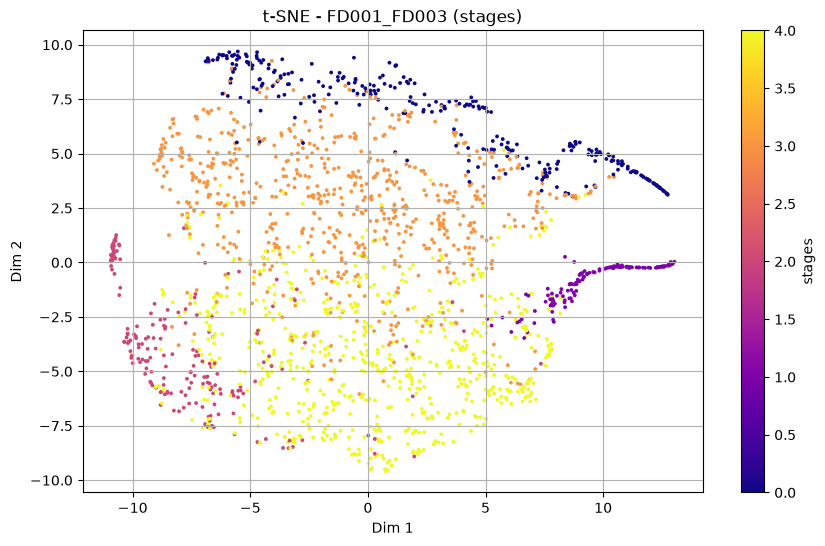

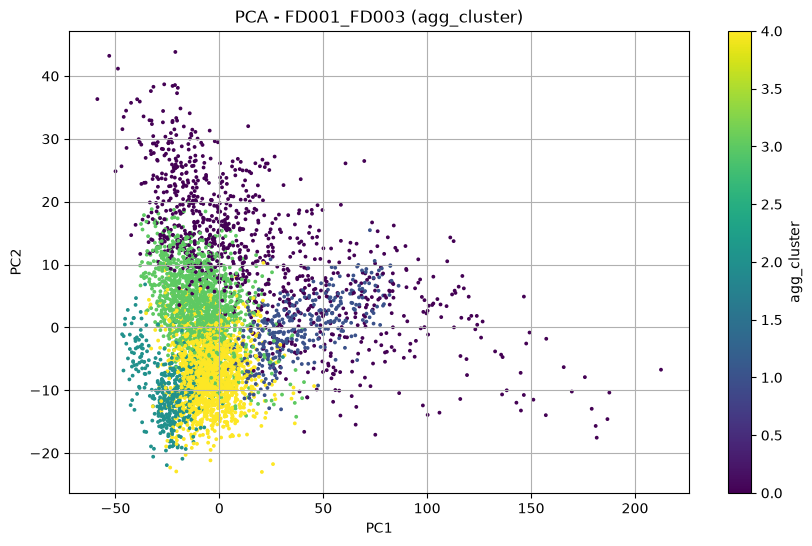

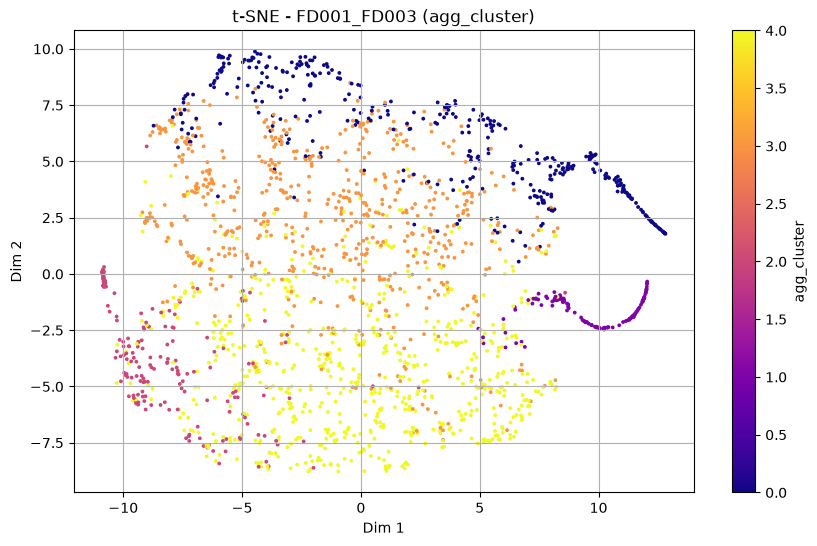

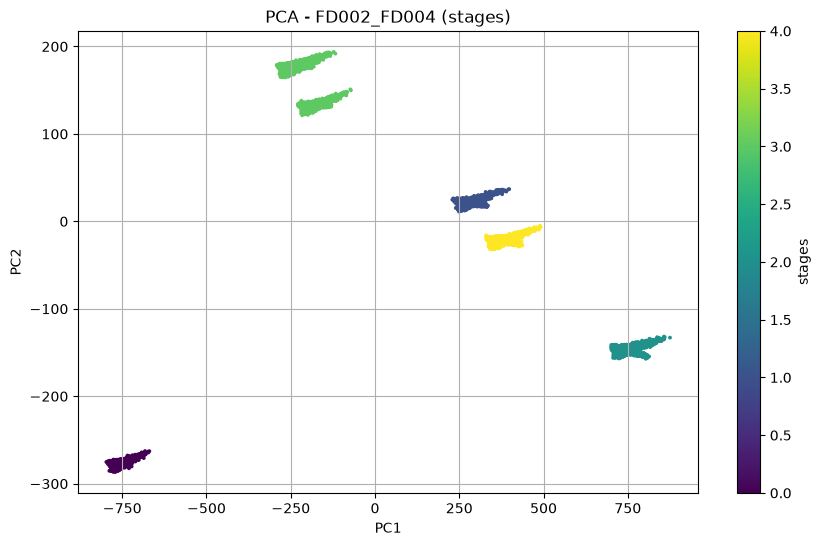

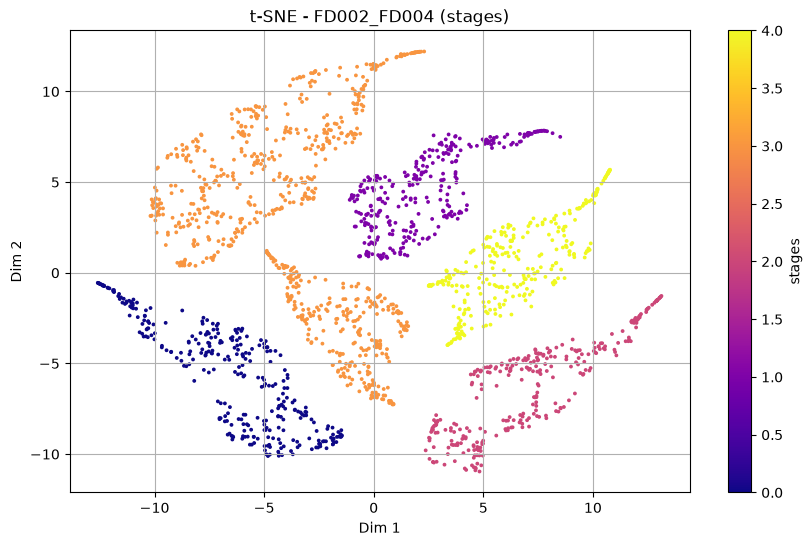

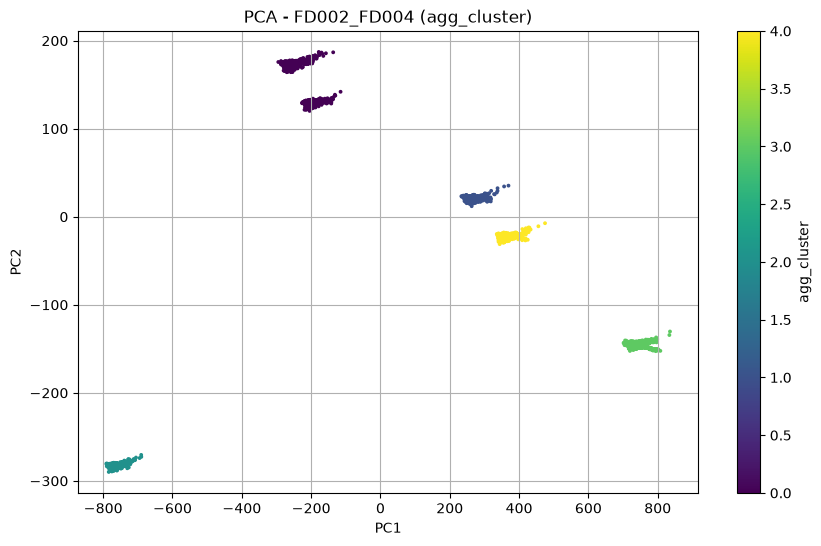

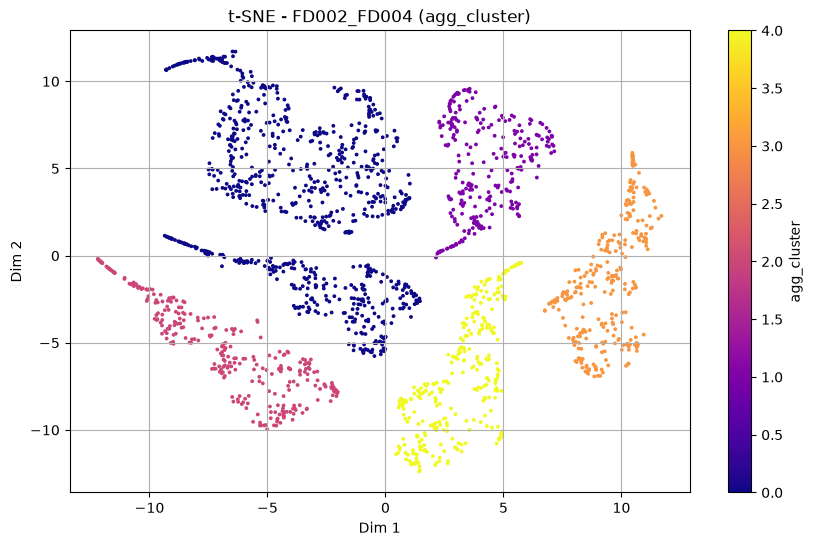

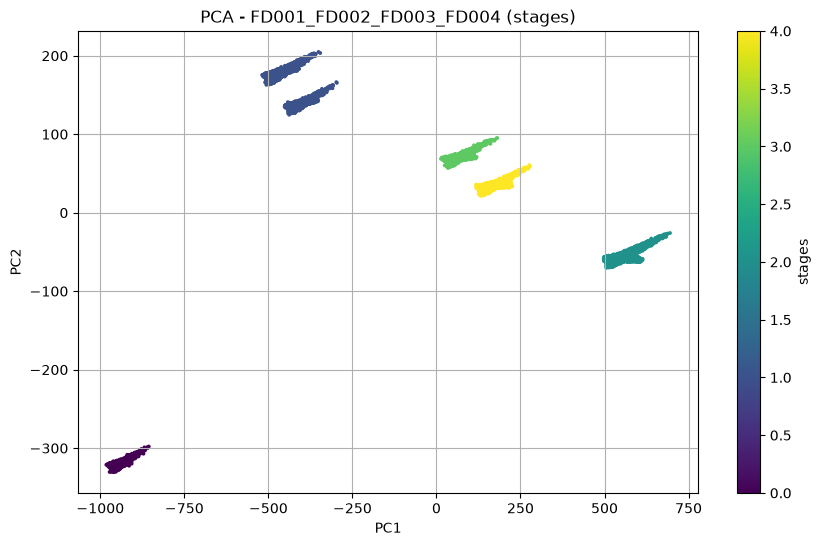

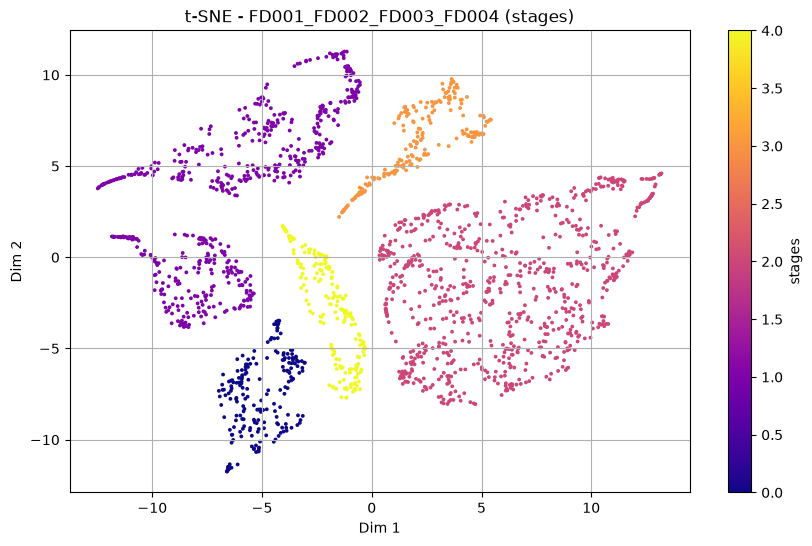

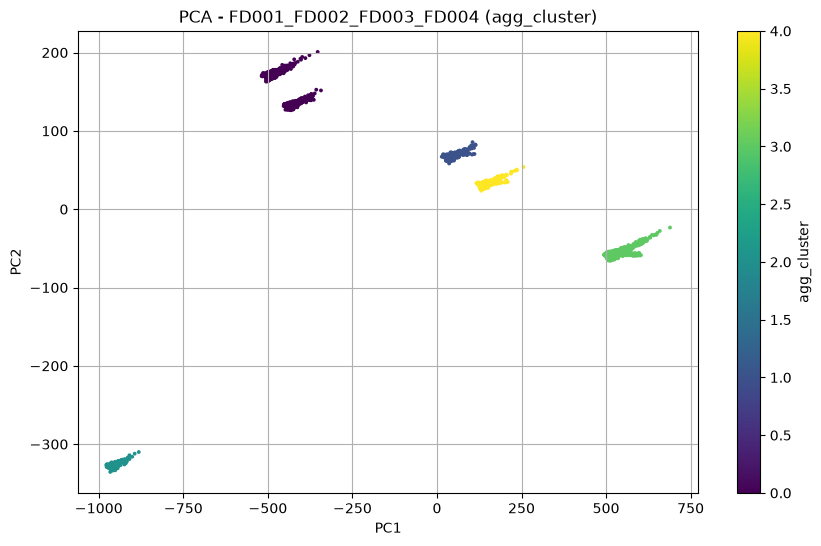

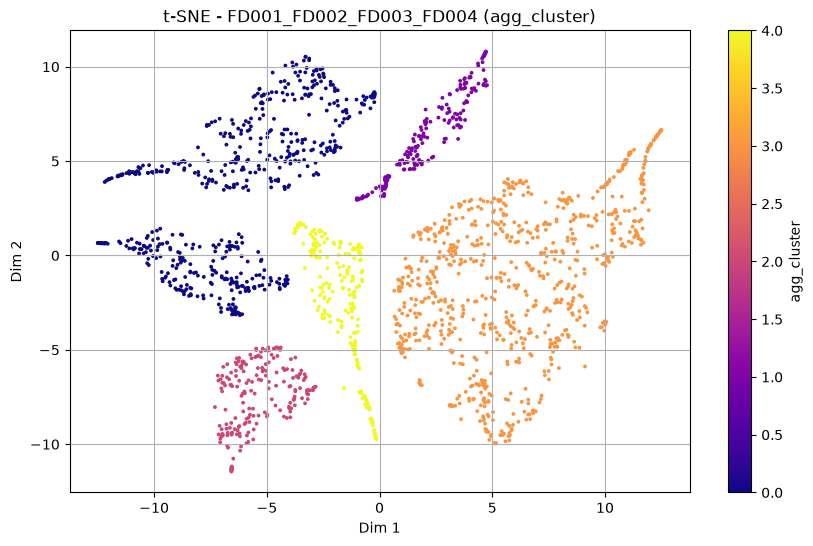

In [7]:
# PCA and t-SNE Visualization
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def visualize_pca(df, title, label_col):
    features = df.drop(['unit','time','cluster','stages','agg_cluster'], axis=1, errors='ignore')
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(features)

    plt.figure(figsize=(10,6))
    plt.scatter(reduced[:,0], reduced[:,1], c=df[label_col], cmap='viridis', s=3)
    plt.title(f"PCA - {title} ({label_col})")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.colorbar(label=label_col)
    plt.grid(True)
    plt.show()

def visualize_tsne(df, title, label_col):
    features = df.drop(['unit','time','cluster','stages','agg_cluster'], axis=1, errors='ignore')
    tsne = TSNE(n_components=2, perplexity=30, max_iter=300, random_state=42)
    reduced = tsne.fit_transform(features)

    plt.figure(figsize=(10,6))
    plt.scatter(reduced[:,0], reduced[:,1], c=df[label_col], cmap='plasma', s=3)
    plt.title(f"t-SNE - {title} ({label_col})")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.colorbar(label=label_col)
    plt.grid(True)
    plt.show()

for combo_name in clustered_data:
    df = clustered_data[combo_name]['raw']
    visualize_pca(df, combo_name, 'stages')
    visualize_tsne(df.sample(n=2000, random_state=42), combo_name, 'stages')
    visualize_pca(df[df['agg_cluster'] != -1], combo_name, 'agg_cluster')
    visualize_tsne(df[df['agg_cluster'] != -1].sample(n=2000, random_state=42), combo_name, 'agg_cluster')

In [8]:
# Save processed data
for name, dataset in clustered_data.items():
    dataset['raw'].to_csv(f"labeled_train_data_{name}.csv", index=False)

In [9]:
# PHASE-2(CLASSIFICATION USING RANDOM FOREST)
# import libraries for model training, evalution, visualization
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

#Load labeled data
import pandas as pd

data1 = pd.read_csv("labeled_train_data_FD001_FD003.csv")
data2 = pd.read_csv("labeled_train_data_FD002_FD004.csv")
data3 = pd.read_csv("labeled_train_data_FD001_FD002_FD003_FD004.csv")

all_datasets = [(data1, "FD001+FD003"), (data2, "FD002+FD004"), (data3, "FD001+FD002+FD003+FD004")]

In [10]:
#Add Rolling Statistics

rolling_sensors = ['sensor2', 'sensor3', 'sensor4', 'sensor7', 'sensor8', 'sensor11', 'sensor15', 'sensor17']
for idx, (data, name) in enumerate(all_datasets):
    for sensor in rolling_sensors:
        data[sensor + '_mean'] = data.groupby('unit')[sensor].rolling(window=5, min_periods=1).mean().reset_index(level=0, drop=True)
        data[sensor + '_std'] = data.groupby('unit')[sensor].rolling(window=5, min_periods=1).std().reset_index(level=0, drop=True)
    data.fillna(0, inplace=True)
    all_datasets[idx] = (data, name)

In [11]:
#Train-Test Split
splits = []
for data, name in all_datasets:
    X = data.drop(['unit', 'time', 'cluster', 'stages'], axis=1)
    Y = data['stages']
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)
    splits.append((X_train, X_test, Y_train, Y_test, X.columns, name))

Random Forest Classification Report (FD001+FD003):
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      1234
           1       0.99      0.99      0.99       575
           2       0.95      0.96      0.95       860
           3       0.95      0.94      0.94      3246
           4       0.96      0.94      0.95      3156

    accuracy                           0.95      9071
   macro avg       0.95      0.96      0.96      9071
weighted avg       0.95      0.95      0.95      9071

Random Forest Classification Report (FD002+FD004):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3428
           1       1.00      1.00      1.00      3443
           2       1.00      1.00      1.00      3456
           3       1.00      1.00      1.00      9211
           4       1.00      1.00      1.00      3464

    accuracy                           1.00     23002
   macro avg       1.00      

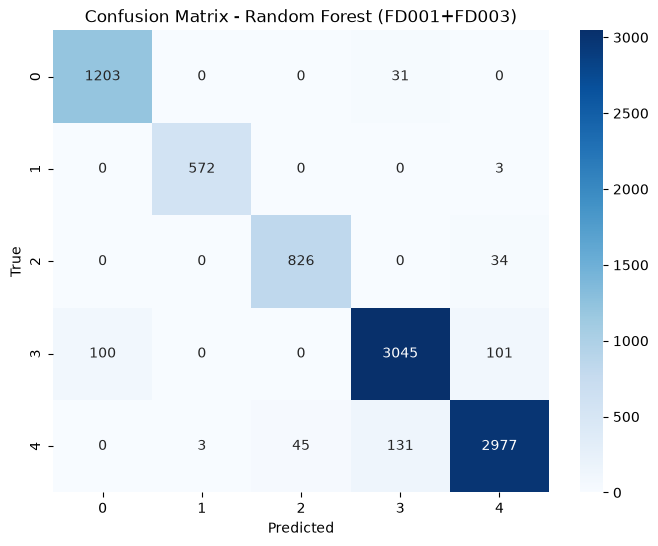

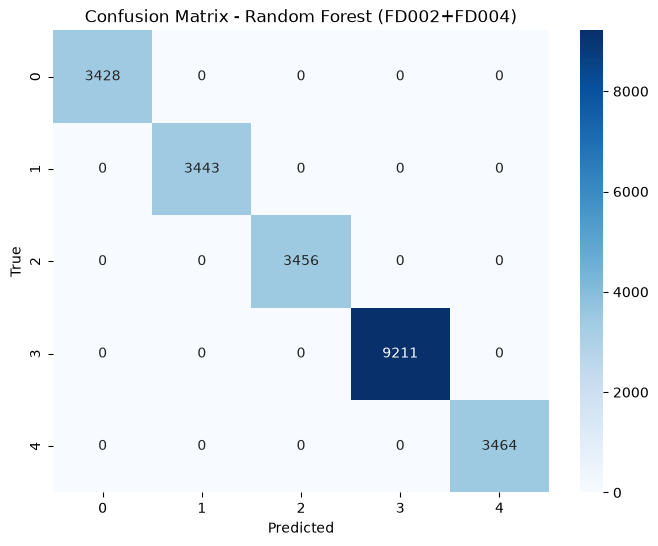

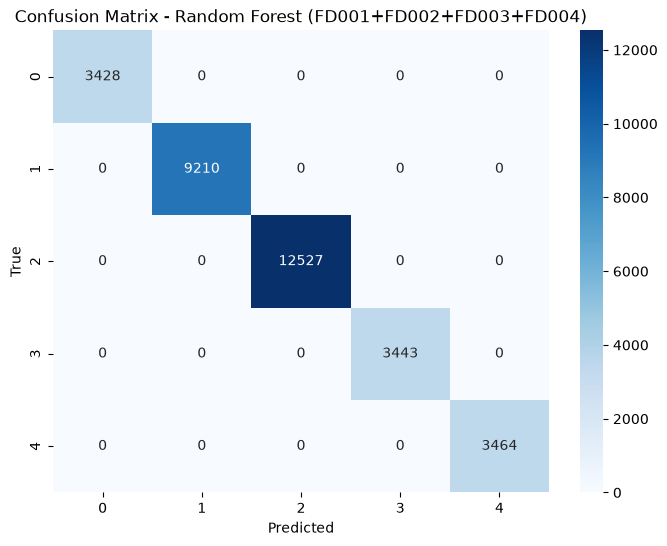

In [12]:
#Random Forest Classifier
rf_models = []
for X_train, X_test, Y_train, Y_test, columns, name in splits:
    rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    rf_model.fit(X_train, Y_train)
    Y_pred_rf = rf_model.predict(X_test)
    print(f"Random Forest Classification Report ({name}):")
    print(classification_report(Y_test, Y_pred_rf))

    #Confusion Matrix
    cm = confusion_matrix(Y_test, Y_pred_rf)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix - Random Forest ({name})')
    plt.show()

    rf_models.append((rf_model, X_train, X_test, Y_train, Y_test, columns, name))

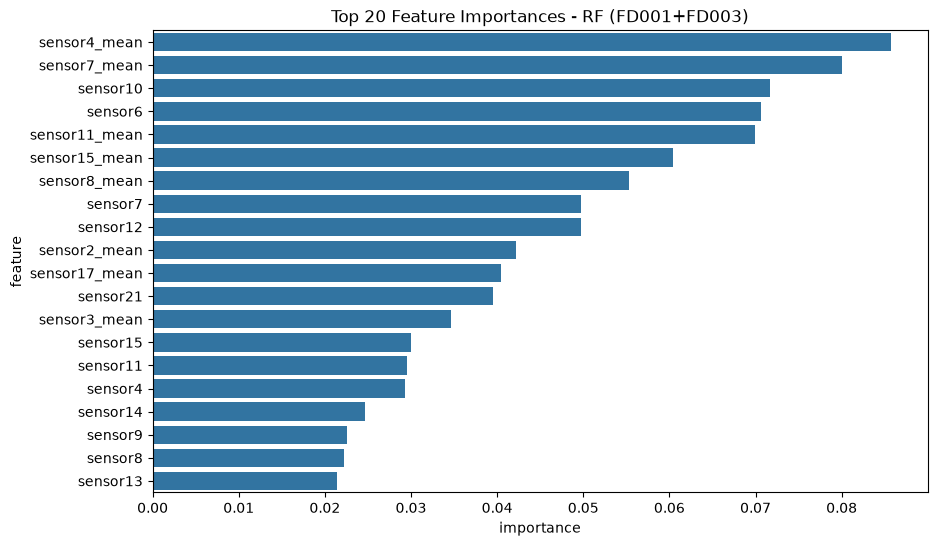

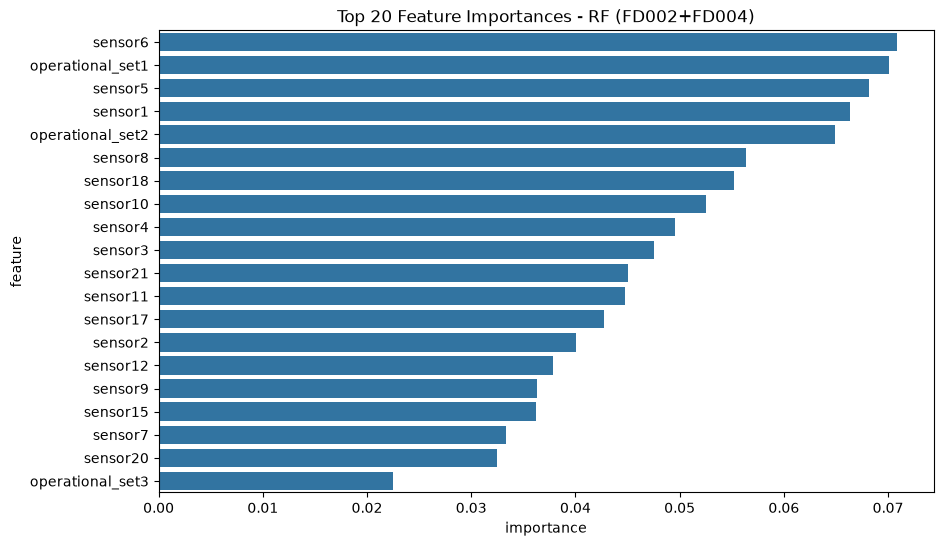

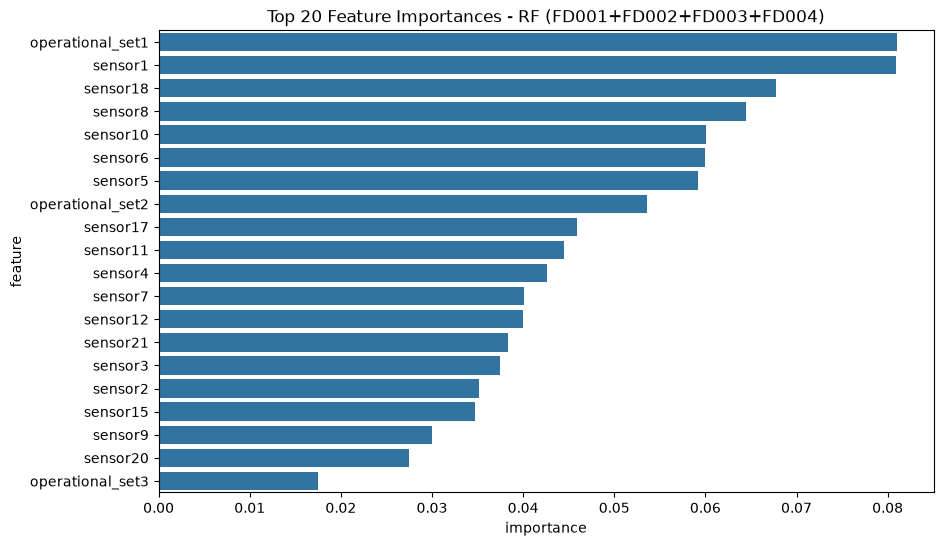

In [13]:
# Plot Feature Importance from Random Forest
for rf_model, _, _, _, _, columns, name in rf_models:
    importances = rf_model.feature_importances_
    feat_imp = pd.DataFrame({'feature': columns, 'importance': importances}).sort_values(by='importance', ascending=False)
    plt.figure(figsize=(10,6))
    sns.barplot(data=feat_imp.head(20), x='importance', y='feature')
    plt.title(f'Top 20 Feature Importances - RF ({name})')
    plt.show()


Logistic Regression Classification Report (FD001+FD003):
              precision    recall  f1-score   support

           0       0.86      0.96      0.91      1234
           1       0.88      0.98      0.93       575
           2       0.77      0.89      0.83       860
           3       0.92      0.88      0.90      3246
           4       0.90      0.84      0.87      3156

    accuracy                           0.88      9071
   macro avg       0.87      0.91      0.89      9071
weighted avg       0.89      0.88      0.88      9071


Logistic Regression Classification Report (FD002+FD004):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3428
           1       1.00      1.00      1.00      3443
           2       1.00      1.00      1.00      3456
           3       1.00      1.00      1.00      9211
           4       1.00      1.00      1.00      3464

    accuracy                           1.00     23002
   macro avg   

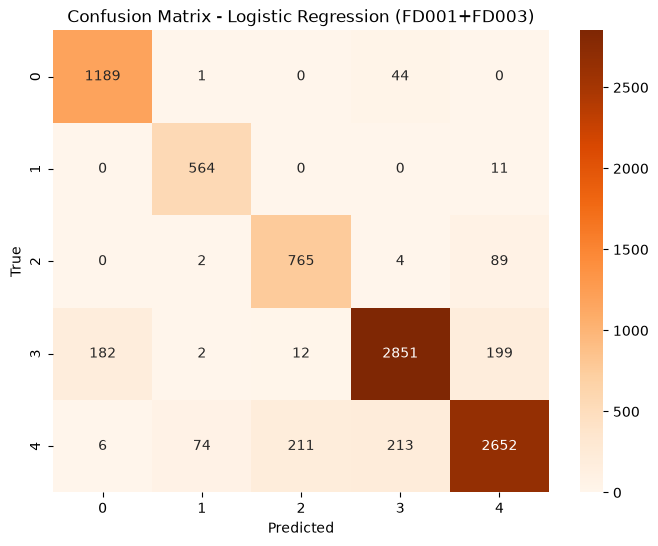

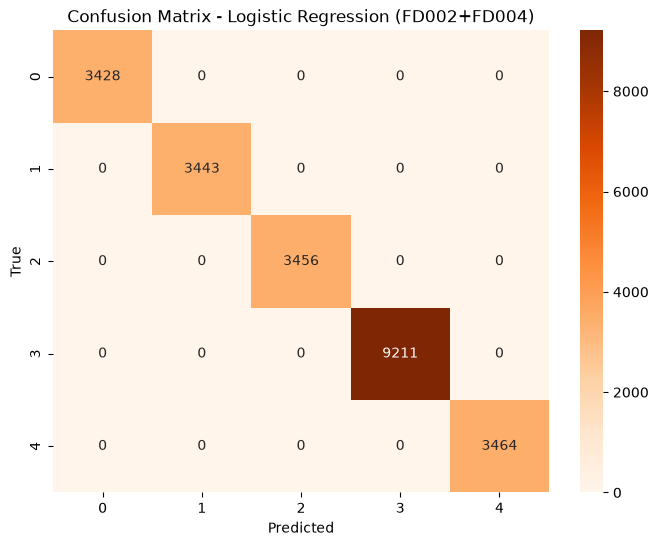

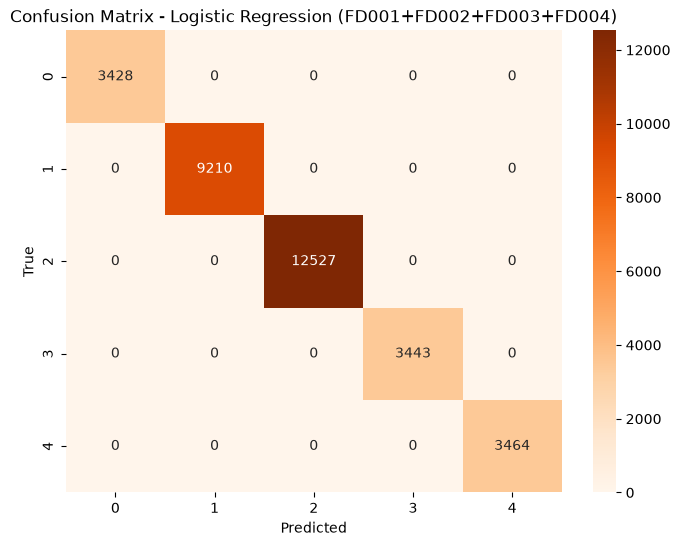

C:\Users\Tanishq Sutrave\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [14]:
#Logistic Regression
for X_train, X_test, Y_train, Y_test, _, name in splits:
    logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    logreg.fit(X_train, Y_train)
    Y_pred_logreg = logreg.predict(X_test)
    print(f"\nLogistic Regression Classification Report ({name}):")
    print(classification_report(Y_test, Y_pred_logreg))

    #Confusion Matrix
    cm_log = confusion_matrix(Y_test, Y_pred_logreg)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm_log, annot=True, fmt='d', cmap='Oranges')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix - Logistic Regression ({name})')
    plt.show()

In [15]:
#Handle Imbalance with SMOTE (help to balance the rare classes)
from imblearn.over_sampling import SMOTE

smote_results = []
for X_train, X_test, Y_train, Y_test, columns, name in splits:
    smote = SMOTE(random_state=42)
    X_train_smote, Y_train_smote = smote.fit_resample(X_train, Y_train)

    rf_model_smote = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    rf_model_smote.fit(X_train_smote, Y_train_smote)
    Y_pred_smote_rf = rf_model_smote.predict(X_test)
    print(f"\nRF After SMOTE ({name}):")
    print(classification_report(Y_test, Y_pred_smote_rf))

    logreg_smote = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    logreg_smote.fit(X_train_smote, Y_train_smote)
    Y_pred_smote_logreg = logreg_smote.predict(X_test)
    print(f"\nLogistic Regression After SMOTE ({name}):")
    print(classification_report(Y_test, Y_pred_smote_logreg))


RF After SMOTE (FD001+FD003):
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      1234
           1       0.99      0.99      0.99       575
           2       0.95      0.97      0.96       860
           3       0.95      0.94      0.94      3246
           4       0.96      0.94      0.95      3156

    accuracy                           0.95      9071
   macro avg       0.96      0.96      0.96      9071
weighted avg       0.95      0.95      0.95      9071


Logistic Regression After SMOTE (FD001+FD003):
              precision    recall  f1-score   support

           0       0.87      0.96      0.92      1234
           1       0.88      0.99      0.93       575
           2       0.81      0.88      0.85       860
           3       0.92      0.89      0.90      3246
           4       0.90      0.86      0.88      3156

    accuracy                           0.89      9071
   macro avg       0.88      0.91      0.89      907

C:\Users\Tanishq Sutrave\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



XGBoost Classification Report (FD001+FD003):
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      1234
           1       0.99      0.99      0.99       575
           2       0.98      0.98      0.98       860
           3       0.97      0.98      0.98      3246
           4       0.98      0.98      0.98      3156

    accuracy                           0.98      9071
   macro avg       0.98      0.98      0.98      9071
weighted avg       0.98      0.98      0.98      9071


XGBoost Classification Report (FD002+FD004):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3428
           1       1.00      1.00      1.00      3443
           2       1.00      1.00      1.00      3456
           3       1.00      1.00      1.00      9211
           4       1.00      1.00      1.00      3464

    accuracy                           1.00     23002
   macro avg       1.00      1.00      

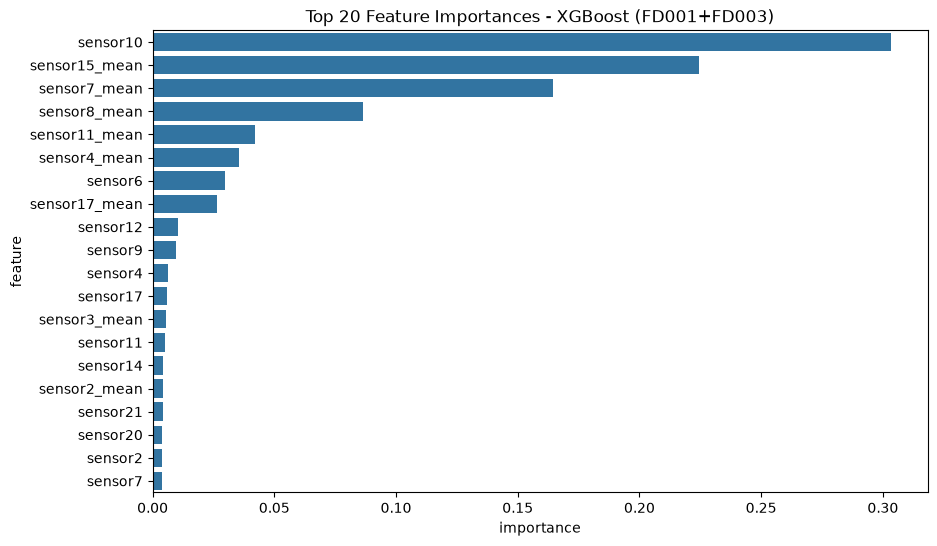

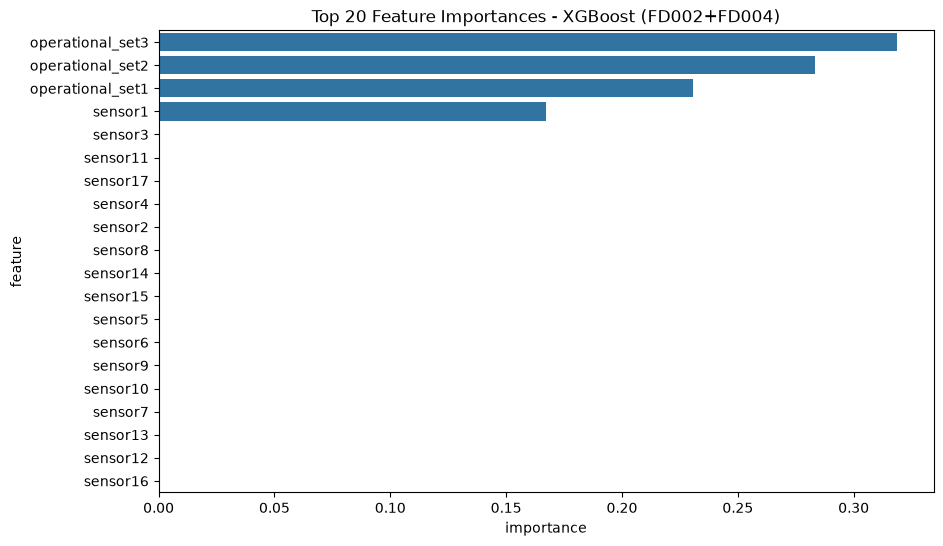

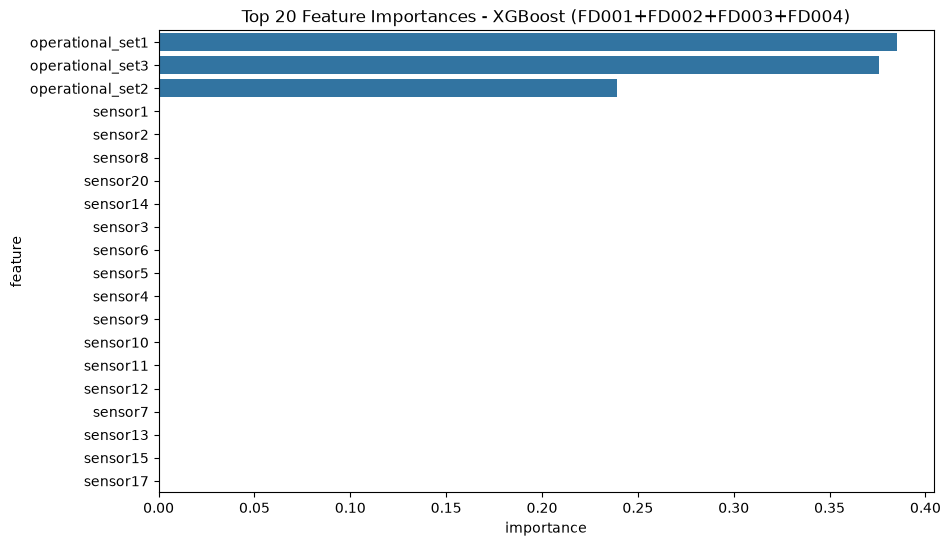

In [16]:
#Train XGBoost Classifier
from xgboost import XGBClassifier

for X_train, X_test, Y_train, Y_test, columns, name in splits:
    xgb = XGBClassifier(eval_metric='mlogloss', random_state=42)
    xgb.fit(X_train, Y_train)
    Y_pred_xgb = xgb.predict(X_test)
    print(f"\nXGBoost Classification Report ({name}):")
    print(classification_report(Y_test, Y_pred_xgb))

    xgb_importance = pd.DataFrame({
        'feature': columns,
        'importance': xgb.feature_importances_
    }).sort_values(by='importance', ascending=False)

    plt.figure(figsize=(10,6))
    sns.barplot(x='importance', y='feature', data=xgb_importance.head(20))
    plt.title(f"Top 20 Feature Importances - XGBoost ({name})")
    plt.show()

In [17]:
# PHASE-3(REGRESSION- TIME TO NEXT DEGRADATION STAGE PREDICTION)

#Import and Load Data
import pandas as pd
import numpy as np

reg1 = pd.read_csv("labeled_train_data_FD001_FD003.csv")
reg2 = pd.read_csv("labeled_train_data_FD002_FD004.csv")
reg3 = pd.read_csv("labeled_train_data_FD001_FD002_FD003_FD004.csv")

reg_datasets = [(reg1, "FD001+FD003"), (reg2, "FD002+FD004"), (reg3, "FD001+FD002+FD003+FD004")]

In [18]:
#Compute Time to Next Stage
def compute_next_stage(df):
    df_sort = df.sort_values(['unit', 'time']).copy()
    df_sort['time_to_next_stage'] = np.nan

    for uid in df_sort['unit'].unique():
        unit_df = df_sort[df_sort['unit'] == uid].copy().reset_index()
        stages = unit_df['stages'].values
        time_left = [0] * len(stages)

        for i in range(len(stages)):
            count = 0
            for j in range(i + 1, len(stages)):
                count += 1
                if stages[j] != stages[i]:
                    time_left[i] = count
                    break

        df_sort.loc[unit_df['index'], 'time_to_next_stage'] = time_left

    df_sort = df_sort[df_sort['time_to_next_stage'] > 0]
    return df_sort

In [19]:
#Apply Time to Next Stage Computation
processed_reg = []
for df, name in reg_datasets:
    updated = compute_next_stage(df)
    processed_reg.append((updated, name))


Random Forest Regressor Results (FD001+FD003):
MAE: 19.145562740443644
RMSE: 34.691525729203505
R^2: 0.09308554297525995

Random Forest Regressor Results (FD002+FD004):
MAE: 0.5221652902175178
RMSE: 0.7735085533754196
R^2: 0.059876954454528675

Random Forest Regressor Results (FD001+FD002+FD003+FD004):
MAE: 0.5281430837155472
RMSE: 0.8017584381106146
R^2: -0.006870445182023843


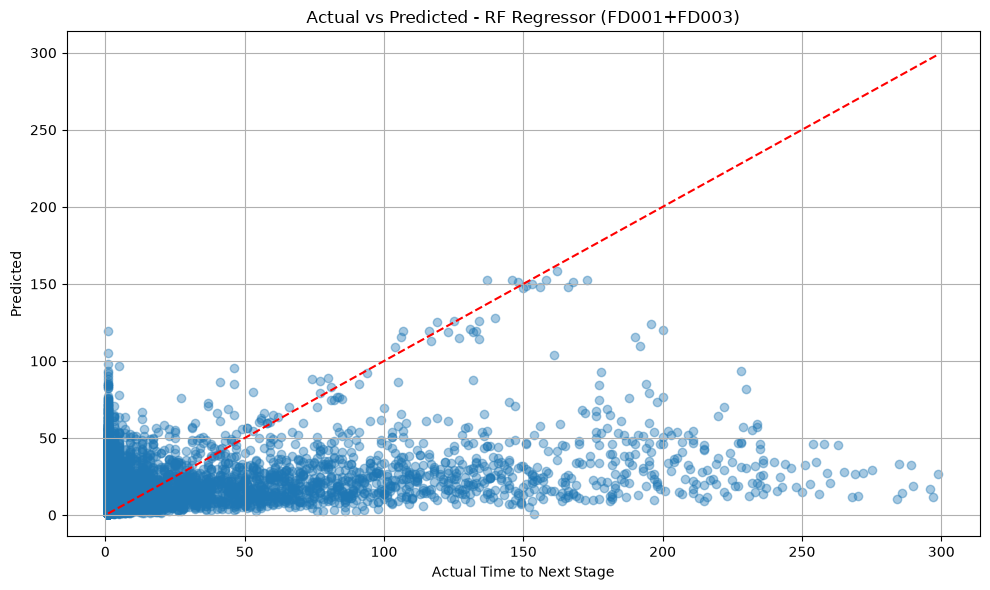

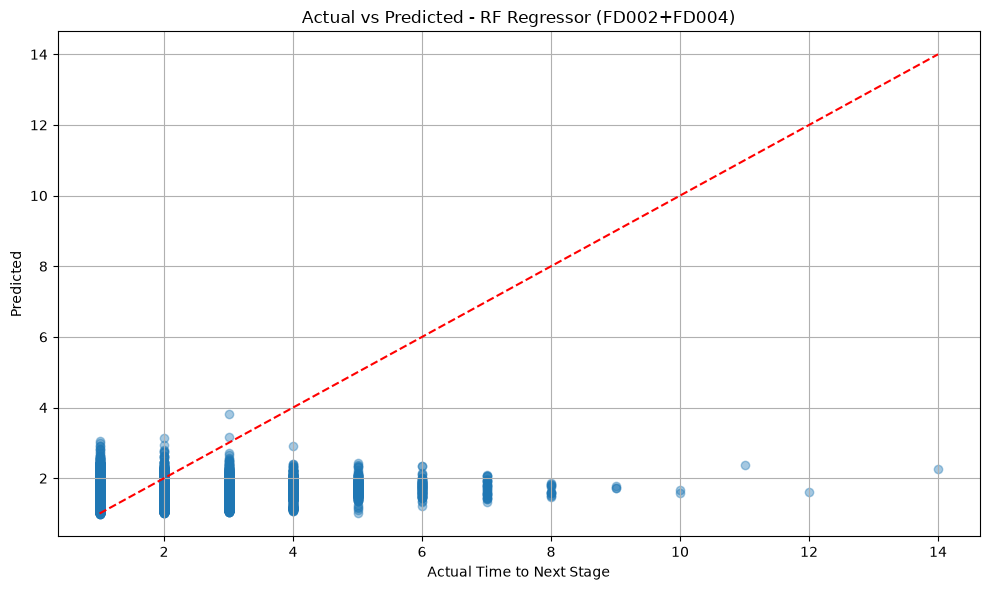

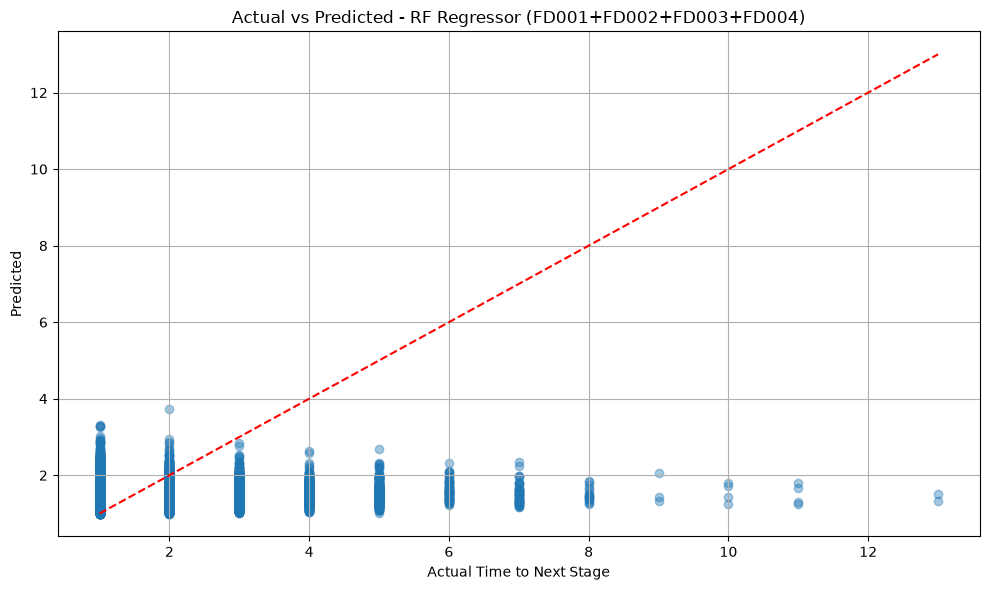

In [20]:
#Import libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

#Train and Evaluate Random Forest Regressor
for df, name in processed_reg:
    X = df.drop(['unit','time','cluster','stages','time_to_next_stage'], axis=1)
    Y = df['time_to_next_stage']

    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

    rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_reg.fit(X_train, Y_train)
    Y_pred = rf_reg.predict(X_test)

    print(f"\nRandom Forest Regressor Results ({name}):")
    print("MAE:", mean_absolute_error(Y_test, Y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(Y_test, Y_pred)))
    print("R^2:", r2_score(Y_test, Y_pred))

    plt.figure(figsize=(10,6))
    plt.scatter(Y_test, Y_pred, alpha=0.4)
    plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')
    plt.xlabel("Actual Time to Next Stage")
    plt.ylabel("Predicted")
    plt.title(f"Actual vs Predicted - RF Regressor ({name})")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


XGBoost Regressor Results (FD001+FD003):
MAE: 19.144283277802323
RMSE: 35.69756826379385
R^2: 0.03972241949983957

XGBoost Regressor Results (FD002+FD004):
MAE: 0.5061943111214317
RMSE: 0.7777681384232717
R^2: 0.04949423739888881

XGBoost Regressor Results (FD001+FD002+FD003+FD004):
MAE: 0.502391683422465
RMSE: 0.7949018432947456
R^2: 0.010277319785371164


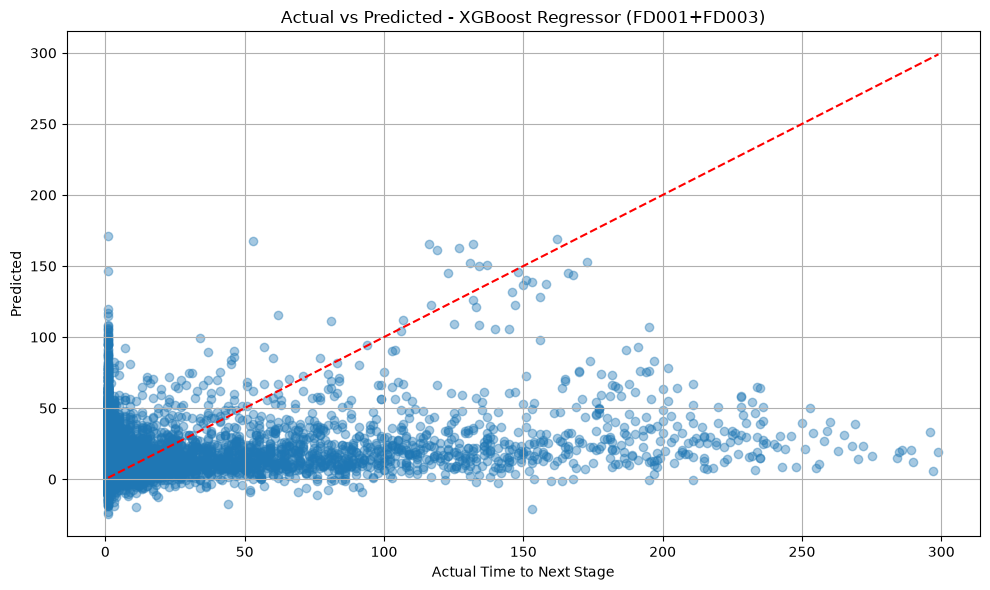

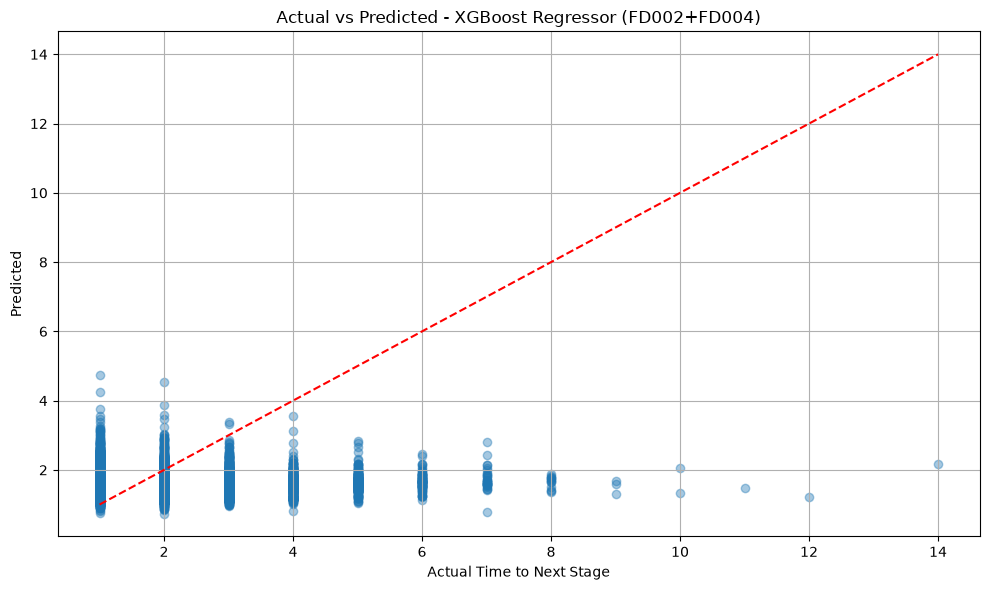

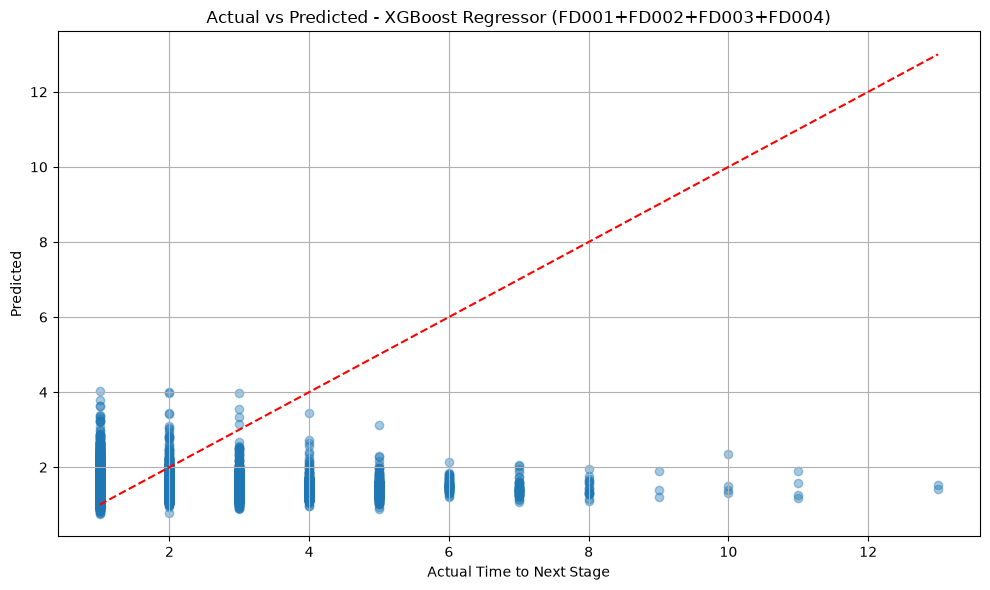

In [21]:
#Train and Evaluate XGBoost Regressor
from xgboost import XGBRegressor

for df, name in processed_reg:
    X = df.drop(['unit','time','cluster','stages','time_to_next_stage'], axis=1)
    Y = df['time_to_next_stage']

    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

    xgb_reg = XGBRegressor(n_estimators=100, random_state=42)
    xgb_reg.fit(X_train, Y_train)
    Y_pred = xgb_reg.predict(X_test)

    print(f"\nXGBoost Regressor Results ({name}):")
    print("MAE:", mean_absolute_error(Y_test, Y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(Y_test, Y_pred)))
    print("R^2:", r2_score(Y_test, Y_pred))

    plt.figure(figsize=(10,6))
    plt.scatter(Y_test, Y_pred, alpha=0.4)
    plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')
    plt.xlabel("Actual Time to Next Stage")
    plt.ylabel("Predicted")
    plt.title(f"Actual vs Predicted - XGBoost Regressor ({name})")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [22]:
# PHASE-4 (RISK SCORING)
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
import matplotlib.pyplot as plt

reg1 = pd.read_csv("labeled_train_data_FD001_FD003.csv")
reg2 = pd.read_csv("labeled_train_data_FD002_FD004.csv")
reg3 = pd.read_csv("labeled_train_data_FD001_FD002_FD003_FD004.csv")

combinations = [(reg1, "FD001+FD003"), (reg2, "FD002+FD004"), (reg3, "FD001+FD002+FD003+FD004")]

In [23]:
#Define compute_next_stage function
def compute_next_stage(df):
    df_sort = df.sort_values(['unit', 'time']).copy()
    df_sort['time_to_next_stage'] = np.nan

    for uid in df_sort['unit'].unique():
        unit_df = df_sort[df_sort['unit'] == uid].copy().reset_index()
        stages = unit_df['stages'].values
        time_left = [0] * len(stages)

        for i in range(len(stages)):
            count = 0
            for j in range(i + 1, len(stages)):
                count += 1
                if stages[j] != stages[i]:
                    time_left[i] = count
                    break

        df_sort.loc[unit_df['index'], 'time_to_next_stage'] = time_left

    df_sort = df_sort[df_sort['time_to_next_stage'] > 0]
    return df_sort

In [24]:
#Train Classifier and Predict Stage 4 Probability
for i in range(len(combinations)):
    df, name = combinations[i]
    X_class = df.drop(['unit','time','cluster','stages'], axis=1)
    Y_class = df['stages']
    clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    clf.fit(X_class, Y_class)
    df['P_stage_4'] = clf.predict_proba(X_class)[:, 4]
    combinations[i] = (df, name)

In [25]:
#Compute Time to Next Stage
for i in range(len(combinations)):
    df, name = combinations[i]
    reg_df = compute_next_stage(df)
    combinations[i] = (reg_df, name)

In [26]:
#Train Regressor and Predict Time to Next Stage (with sampling)
for i in range(len(combinations)):
    reg_df, name = combinations[i]
    if len(reg_df) > 30000:
        reg_df = reg_df.sample(n=30000, random_state=42)
    X_reg = reg_df.drop(['unit','time','cluster','stages','time_to_next_stage','P_stage_4'], axis=1)
    Y_reg = reg_df['time_to_next_stage']
    reg = RandomForestRegressor(n_estimators=100, random_state=42)
    reg.fit(X_reg, Y_reg)
    reg_df['predicted_time_to_next_stage'] = reg.predict(X_reg)
    combinations[i] = (reg_df, name)

In [27]:
#Compute Risk Scores
for i in range(len(combinations)):
    reg_df, name = combinations[i]
    reg_df['raw_risk_score'] = reg_df['P_stage_4'] * reg_df['predicted_time_to_next_stage']

    min_risk, max_risk = reg_df['raw_risk_score'].min(), reg_df['raw_risk_score'].max()

    reg_df['normalized_risk_score'] = (reg_df['raw_risk_score'] - min_risk) / (max_risk - min_risk)
    reg_df['inverted_risk_score'] = reg_df['P_stage_4'] / (reg_df['predicted_time_to_next_stage'] + 1e-6)
    combinations[i] = (reg_df, name)

In [28]:
#Trigger Maintenance Alerts
for i in range(len(combinations)):
    reg_df, name = combinations[i]
    reg_df['alert'] = reg_df['normalized_risk_score'].apply(lambda x: "⚠️ Maintenance Alert!" if x > 0.7 else "")
    combinations[i] = (reg_df, name)


Top High-Risk Units - FD001+FD003
       unit  time  ...  normalized_risk_score                  alert
16382    82     5  ...               1.000000  ⚠️ Maintenance Alert!
1716      9     4  ...               0.997077  ⚠️ Maintenance Alert!
1720      9     8  ...               0.994845  ⚠️ Maintenance Alert!
40773    82    17  ...               0.984658  ⚠️ Maintenance Alert!
35598    59     4  ...               0.983316  ⚠️ Maintenance Alert!
40764    82     8  ...               0.977573  ⚠️ Maintenance Alert!
16387    82    10  ...               0.977089  ⚠️ Maintenance Alert!
35597    59     3  ...               0.969950  ⚠️ Maintenance Alert!
40757    82     1  ...               0.963777  ⚠️ Maintenance Alert!
1713      9     1  ...               0.959752  ⚠️ Maintenance Alert!

[10 rows x 6 columns]

Top High-Risk Units - FD002+FD004
       unit  time  ...  normalized_risk_score                  alert
15665    80   102  ...               1.000000  ⚠️ Maintenance Alert!
48327   23

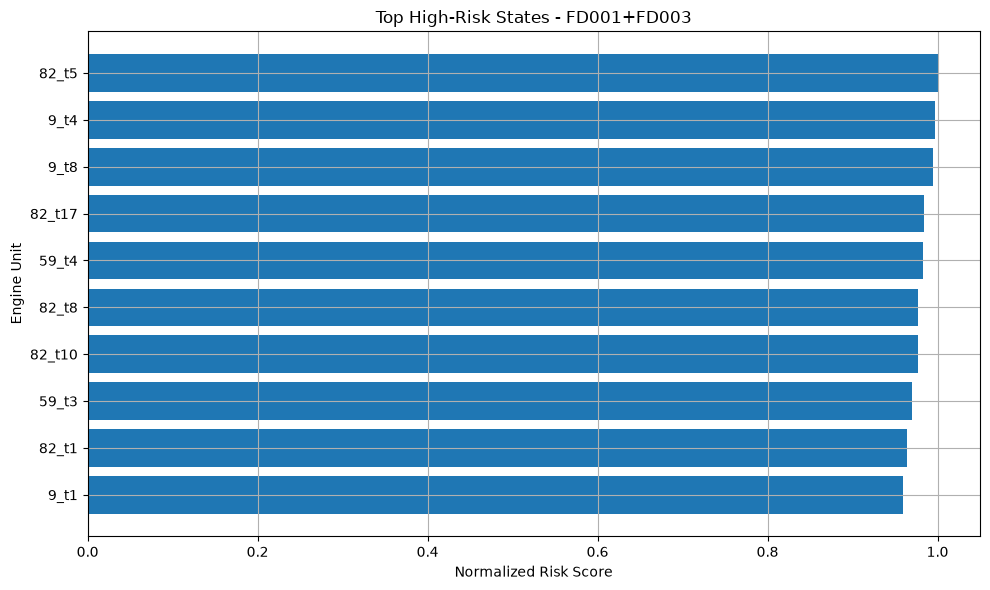

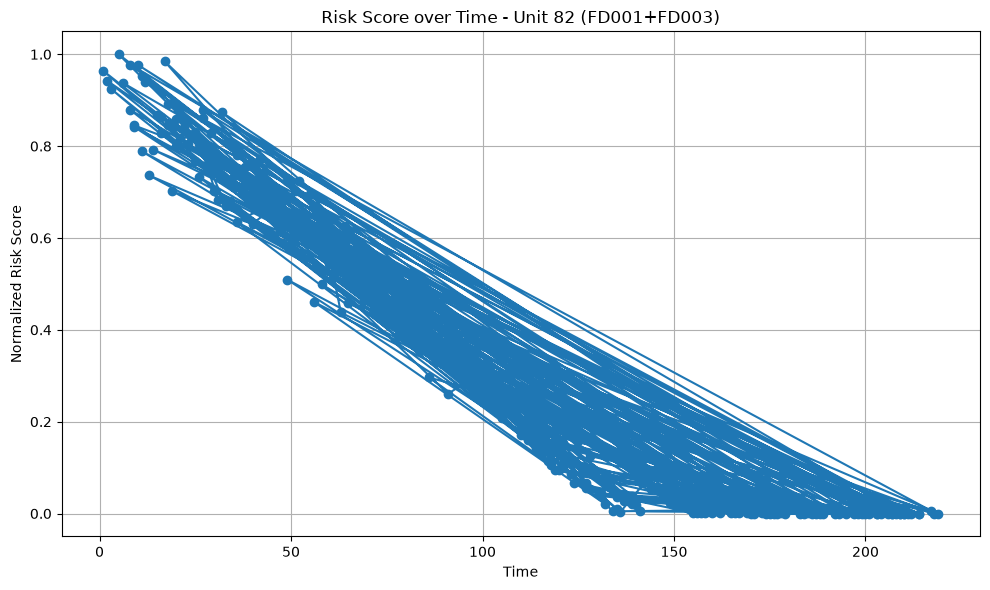

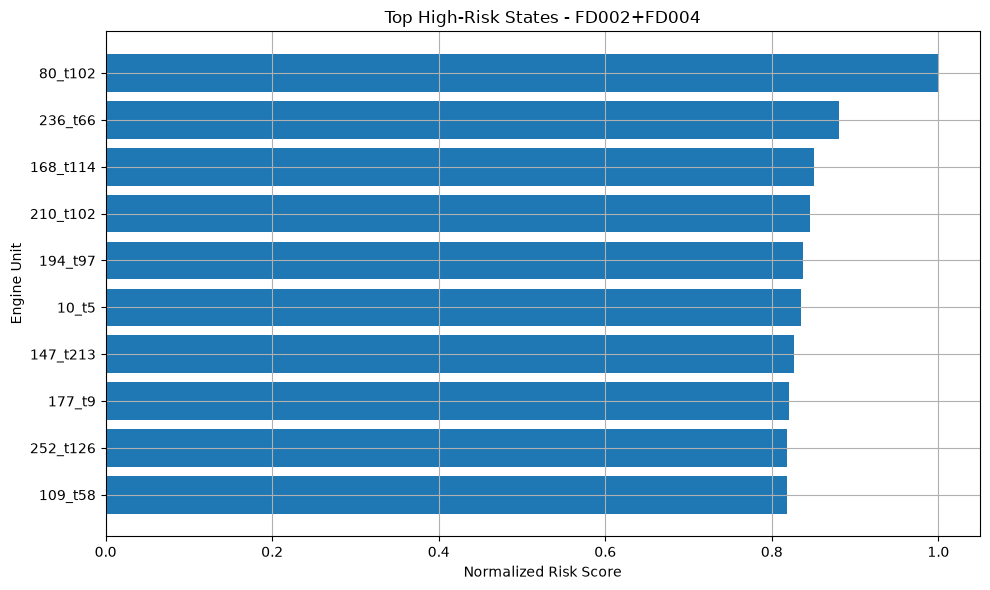

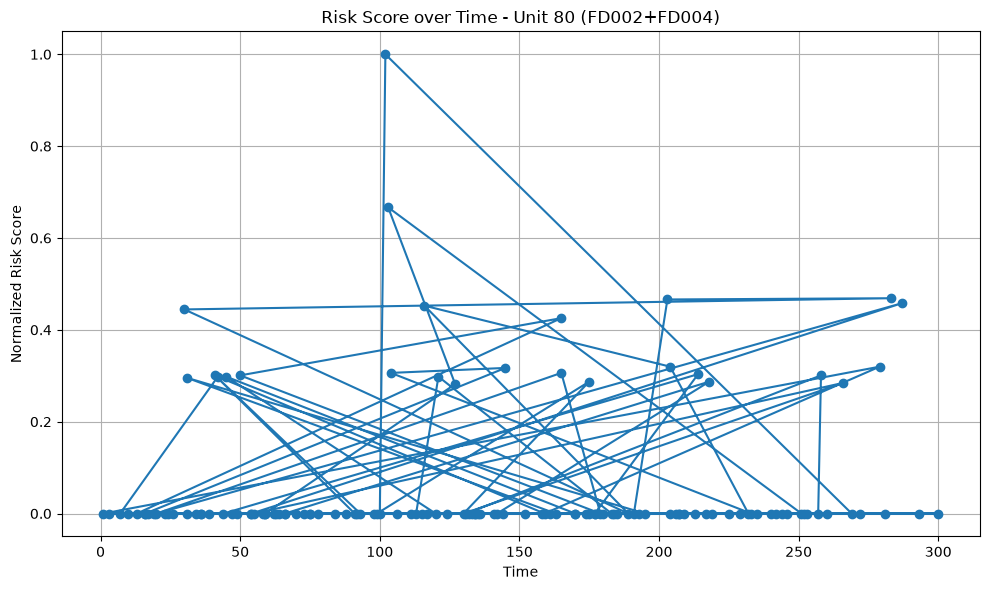

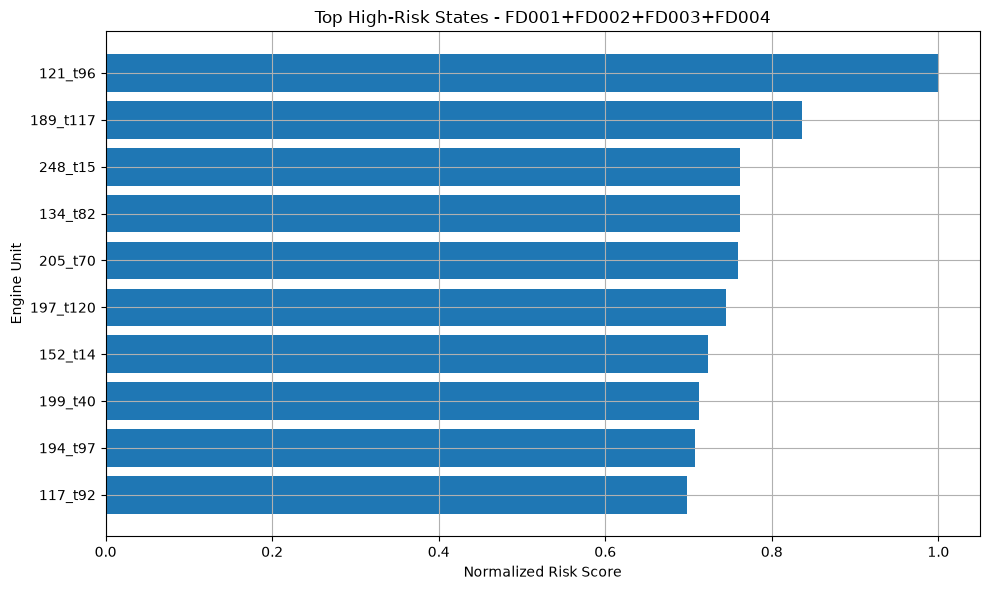

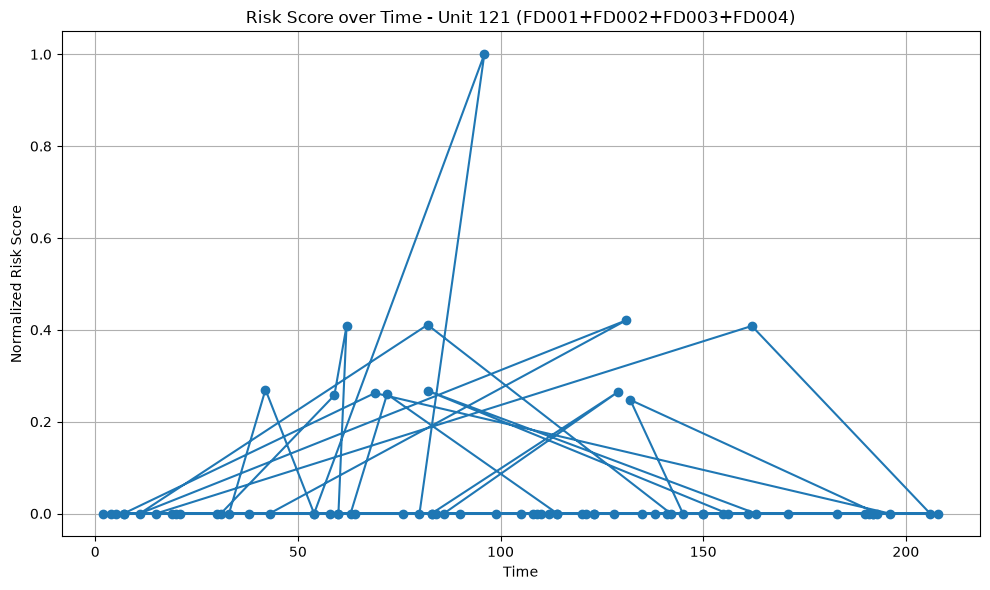

In [29]:
#Display and Plot Risk Insights
for reg_df, name in combinations:
    risk_rank = reg_df.sort_values(by='normalized_risk_score', ascending=False)
    print(f"\nTop High-Risk Units - {name}")
    print(risk_rank[['unit','time','P_stage_4','predicted_time_to_next_stage','normalized_risk_score','alert']].head(10))

    top_risk = risk_rank.head(10)
    plt.figure(figsize=(10,6))
    plt.barh(top_risk['unit'].astype(str)+"_t"+top_risk['time'].astype(int).astype(str), top_risk['normalized_risk_score'])
    plt.xlabel("Normalized Risk Score")
    plt.ylabel("Engine Unit")
    plt.title(f"Top High-Risk States - {name}")
    plt.gca().invert_yaxis()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    unit_id = int(risk_rank.iloc[0]['unit'])
    unit_data = reg_df[reg_df['unit'] == unit_id]
    plt.figure(figsize=(10,6))
    plt.plot(unit_data['time'], unit_data['normalized_risk_score'], marker='o')
    plt.xlabel("Time")
    plt.ylabel("Normalized Risk Score")
    plt.title(f"Risk Score over Time - Unit {unit_id} ({name})")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

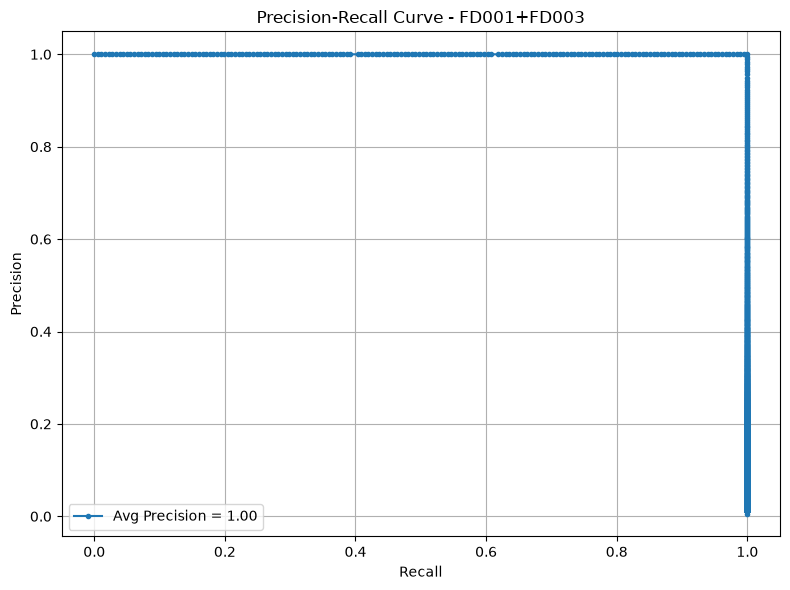

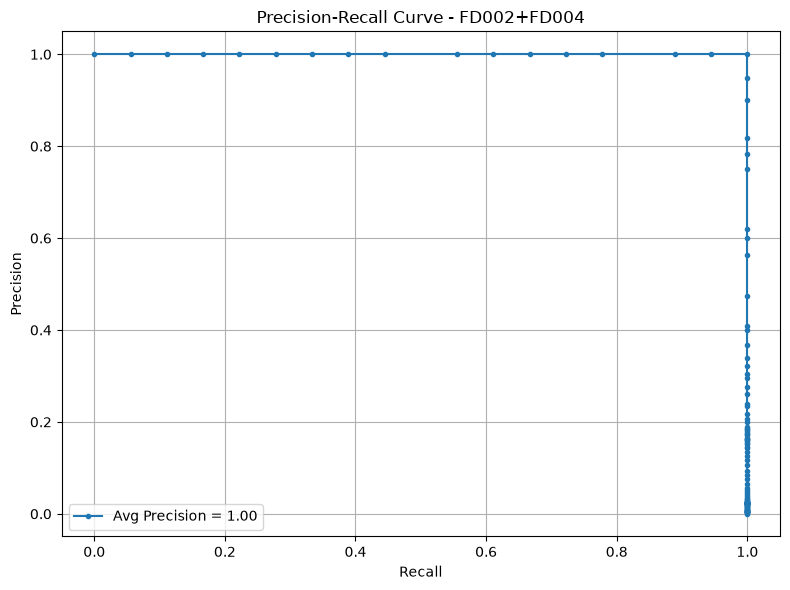

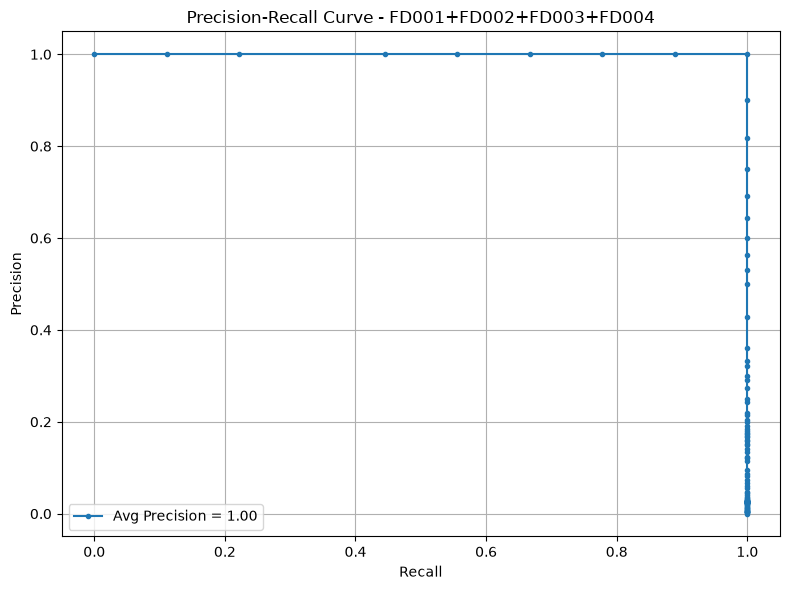

In [30]:
#Precision-Recall Curve for Threshold Tuning
from sklearn.metrics import precision_recall_curve, average_precision_score

for reg_df, name in combinations:
    y_true = (reg_df['normalized_risk_score'] > 0.7).astype(int)
    y_scores = reg_df['normalized_risk_score']
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    avg_precision = average_precision_score(y_true, y_scores)

    plt.figure(figsize=(8,6))
    plt.plot(recall, precision, marker='.', label=f'Avg Precision = {avg_precision:.2f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve - {name}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()